# MPW2 - Computational graphs

In [28]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [29]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [30]:
datafile = r"lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [31]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [32]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

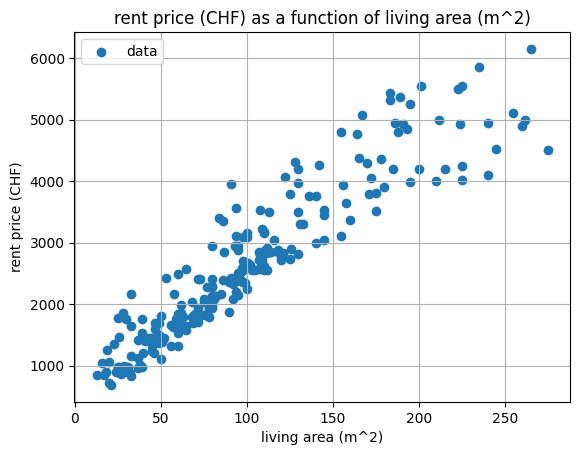

In [33]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


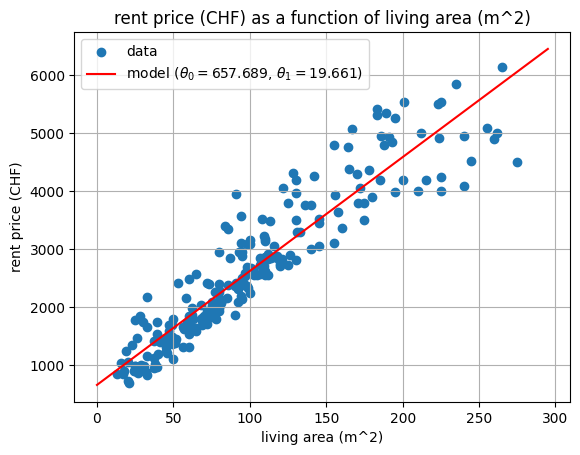

In [34]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = np.linalg.inv(X.T @ X) @ X.T @ y # TO COMPLETE

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [35]:
def mse_loss(y_hat, y):
    N = len(y)
    return (1 / (2 * N)) * np.sum((y_hat - y) ** 2)

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [36]:
def rmse_loss(y_hat, y):
    return np.sqrt(np.mean((y_hat - y) ** 2))

def mae_loss(y_hat, y):
    return np.mean(np.abs(y_hat - y))

def mape_loss(y_hat, y):
    return np.mean(np.abs((y_hat - y) / y))

y_hat = theta[0] + theta[1] * living_area
    
rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

MSE ≈ 105,000 → mathematically minimized, but large because data is noisy and model is simple.

RMSE ≈ 324 CHF → easier to interpret: average prediction error in rent units.

MAE → typical error size, less sensitive to outliers.

MAPE ≈ 12% → relative error: predictions deviate ~12% from actual rents on average.


If y = 0 (actual rent zero), division by zero → undefined.

For small rents, even tiny errors give huge percentages → misleading.

Not symmetric: over-prediction vs under-prediction percentages differ.

So, MAPE is useful for relative error but must be applied carefully, especially when target values vary widely or include very small numbers.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [37]:
import importlib
import cgnodes
importlib.reload(cgnodes)

from cgnodes import ValueNode, MultiplyNode, AddNode, MSELossNode, CompGraph

In [38]:
### CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()
q = ValueNode()        # intermediate result (theta_1 * x)
y_hat = ValueNode()    # prediction
j = ValueNode()        # loss

# then create all <Operator>Node objects
mul = MultiplyNode(theta_1, x, q)           # q = theta_1 * x
add = AddNode([theta_0, q], y_hat)          # y_hat = theta_0 + q
loss = MSELossNode(y_hat, y, j)             # j = MSE(y_hat, y)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [39]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [40]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [41]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.003024979756869
slope (theta_1)    : 24.28518822153736
The total value of the loss is 163794.98243939804


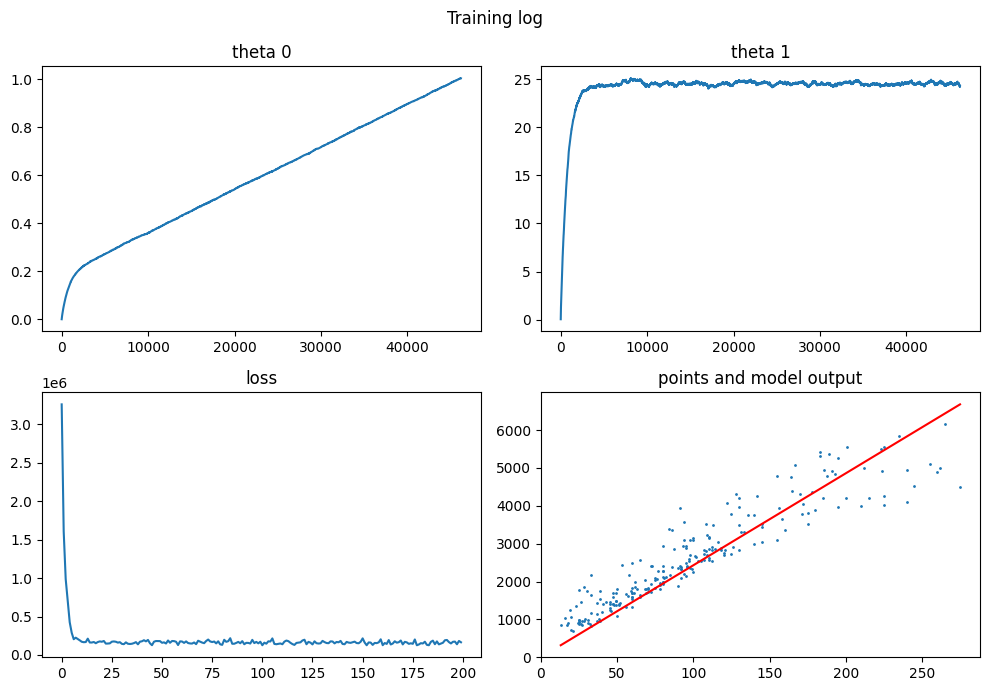

In [42]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- Evolution of the loss: The loss drops a lot in the beginning of the training, then becomes stable with small oscillations. This means that stochastic gradient descent is able to quickly improve the model parameters. The remaining fluctuations are expected because each update is computed from one randomly selected training sample.

- Evolution of theta_1: The parameter converges very quickly toward a value close to 25. It then remains approximately stable, with small variations due to the stochastic nature of the optimization. Since it controls the slope, the model rapidly learns the main linear trend between living area and rent price.

- Evolution of theta_0: The parameter increases slowly throughout training and does not appear to have completely converged. Compared to theta_1, its evolution is much slower. This could be because the scale of the living area makes the gradient of theta_1 larger than the gradient of theta_0.

### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.468494150601119
slope (theta_1)    : 24.46259075695359
The total value of the loss is 163550.95199436808


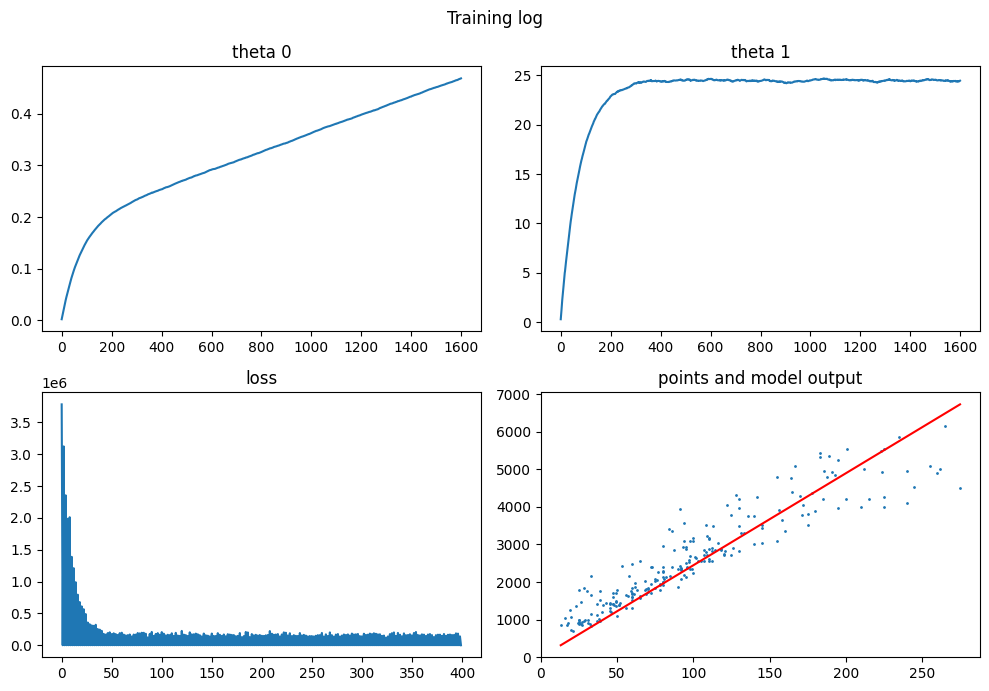

In [43]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_grad_t0 = 0.0
        batch_grad_t1 = 0.0
        batch_loss = 0.0

        for b in range(batch_size):
            n = random.choice(range(0, N))

            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            batch_grad_t0 += theta_0.grad_v
            batch_grad_t1 += theta_1.grad_v
            batch_loss += j.v

        batch_grad_t0 /= batch_size
        batch_grad_t1 /= batch_size
        batch_loss /= batch_size

        t0 = t0 - alpha * batch_grad_t0
        t1 = t1 - alpha * batch_grad_t1

        epoch_loss += batch_loss

        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0


    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**

- Evolution of theta_0 and theta_1: With batched gradient descent, both parameters evolve more smoothly than in the plain stochastic version. theta_1 still increases rapidly at the beginning and then stabilizes around a value close to 25, but a bit slower than the previous version. theta_0 also increases much more slowly and progressively. The loss decreases sharply during the first iterations and then reaches a plateau with smaller fluctuations.

- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? Yes. We still observe that theta_1 converges much faster than theta_0. However, compared to the stochastic version, the curves are smoother because each update uses the average gradient over a batch instead of the gradient of a single random sample.

- Can we use larger learning rates than in the plain stochastic version ? Yes, the learning rate increased from 0.0000001 to 0.000001, and the training remains stable. Since the gradients are averaged over a batch, the updates are less noisy and more stable. This allows us to use a larger learning rate than in plain stochastic gradient descent.

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 660.2942267950493
slope (theta_1)    : 19.7642387396132
The total value of the loss is 105015.6819901122


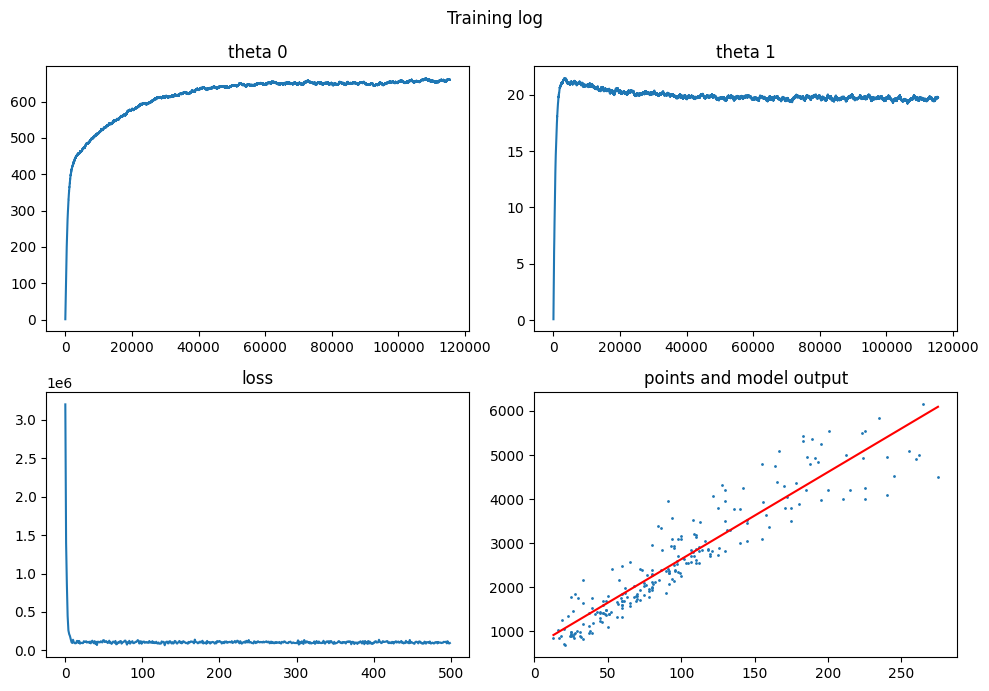

In [44]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**Your observations**

- Using different learning rates improves the evolution of theta_0. Compared to the previous experiments, theta_0 now increases much faster and reaches a value around 650, then starts stabilising. This confirms that the previous learning rate was too small for the intercept parameter.

- theta_1 still converges very quickly at the beginning. It first increases rapidly, then slightly decreases and stabilizes around a value close to 20. The smaller learning rate for theta_1 prevents it from changing too aggressively after the first updates.

- The loss decreases sharply at the beginning and then remains low and relatively stable. The final regression line fits the data reasonably well. This shows that using separate learning rates for each parameter can help balance their convergence speeds: a larger learning rate helps the slow parameter theta_0, while a smaller one keeps the fast parameter theta_1 stable.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 661.4404040602716
slope (theta_1)    : 19.71535726817666
The total value of the loss is 104961.72706044678


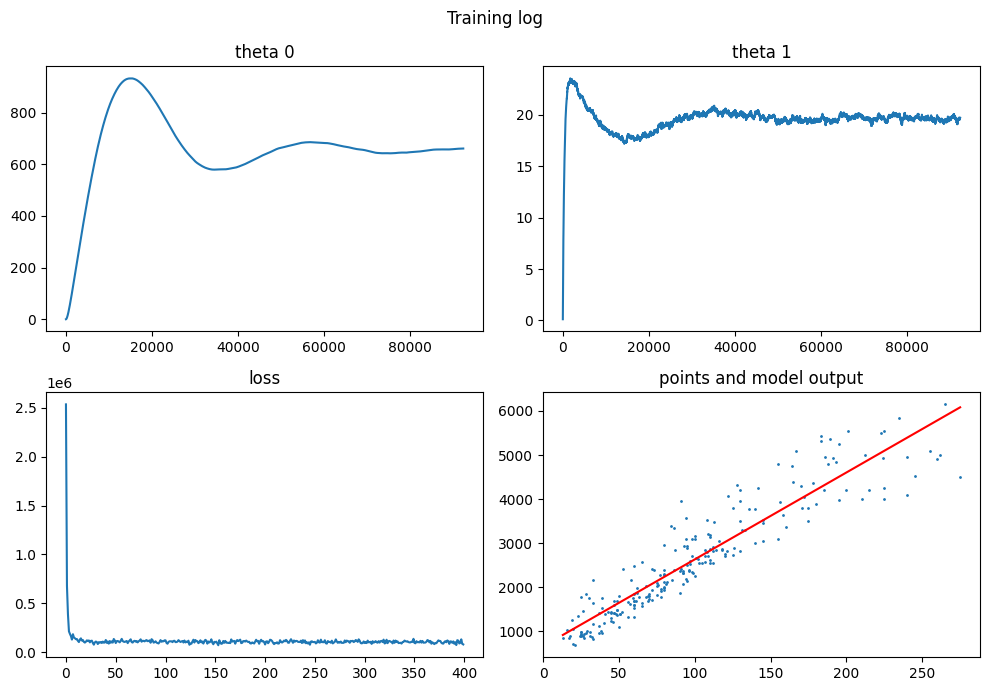

In [45]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

- The momentum optimizer strongly accelerates the evolution of theta_0. Unlike the previous SGD version where theta_0 increased slowly, here it rises very quickly and even overshoots above its final stable value. It then oscillates before progressively stabilizing around 650.

- theta_1 also converges very quickly, but even here the momentum creates some overshooting. It rises higher, then decreases below its final value, and finally stabilizes around 20. This confirms that too much acceleration on a parameter that already converges quickly can create an overshoot and then oscillations.

- The loss decreases very sharply at the beginning and then remains low with small fluctuations. Overall, momentum improves convergence speed, especially for theta_0, but it can also introduce oscillations because the optimizer keeps inertia from previous gradients. It's useful here because theta_0 had gradients mostly going in the same direction, so the accumulated momentum helps it move faster. However, for theta_1, the parameter was already close to convergence, so momentum mostly adds oscillations rather than a large improvement.

In [46]:
baseline_t0 = t0
baseline_t1 = t1
baseline_y_hat = baseline_t0 + baseline_t1 * living_area
baseline_J = mse_loss(baseline_y_hat, rent_price)

baseline_loss_evolution = loss_evolution.copy()
baseline_t0_evolution = t0_evolution.copy()
baseline_t1_evolution = t1_evolution.copy()

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- ✓ Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- ✓ Normalize the input data with a zero norm approach and compare to your experiments without normalization.


### Early stopping strategy

Early stopping at epoch 44
intercept (theta_0): 826.5744555463077
slope (theta_1)    : 18.615666029606373
The total value of the loss is 109061.88951981628


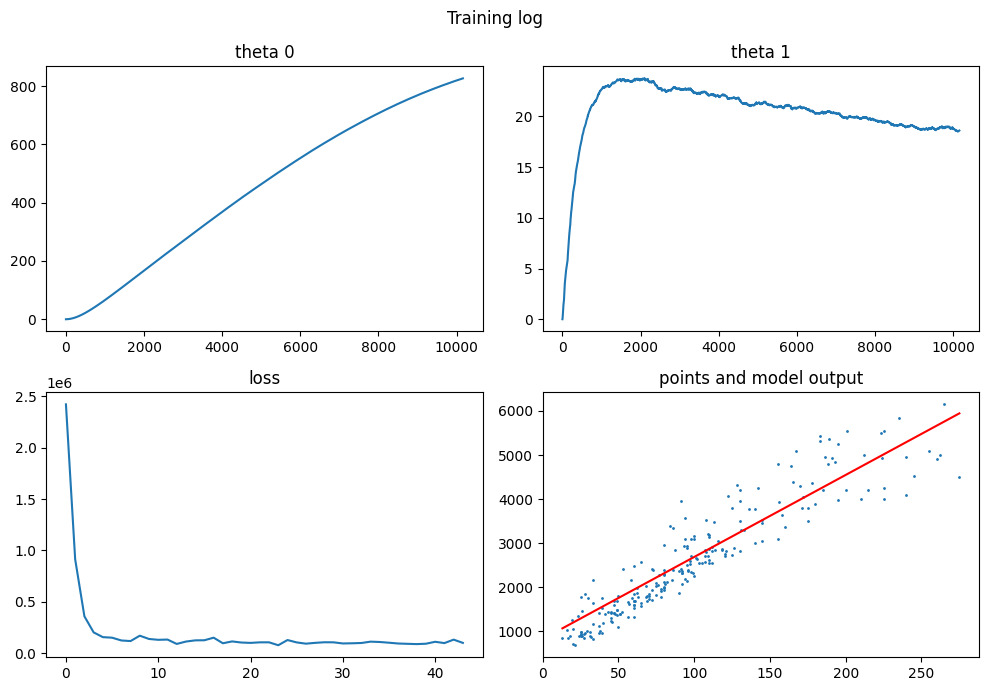

In [47]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

patience = 20
min_delta = 1e-3

N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

best_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    average_epoch_loss = epoch_loss / n_steps
    loss_evolution.append(epoch_loss / n_steps)
    if average_epoch_loss < best_loss - min_delta:
        best_loss = average_epoch_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Observations**

- The early stopping strategy stopped the training much earlier at the epoch 44 instead of running until the maximum number of epochs. This shows that after this point, the loss was no longer improving enough according to the chosen patience and min_delta criteria.

- The loss decreases very quickly during the first epochs, then reaches a plateau around epoch 10. After that, the improvements become small and noisy, so continuing training would not significantly improve the model.

- theta_0 continues to increase during training and reaches around 800 when training stops. theta_1 increases quickly at the beginning, reaches a maximum, then slowly decreases and stabilizes around 18. This shows that the parameters are still moving, but the global loss is no longer improving enough to justify more epochs.

- The final loss is similar to previous results, and the fitted regression line looks reasonable. Early stopping therefore reduces unnecessary computation while keeping a good model.

### Input data normalization with a zero norm approach

In [48]:
living_area_mean = np.mean(living_area)
living_area_std = np.std(living_area)

living_area_norm = (living_area - living_area_mean) / living_area_std

intercept (theta_0): 598.1124921721159
slope (theta_1)    : 20.065739947769444
The total value of the loss is 105405.45634216985


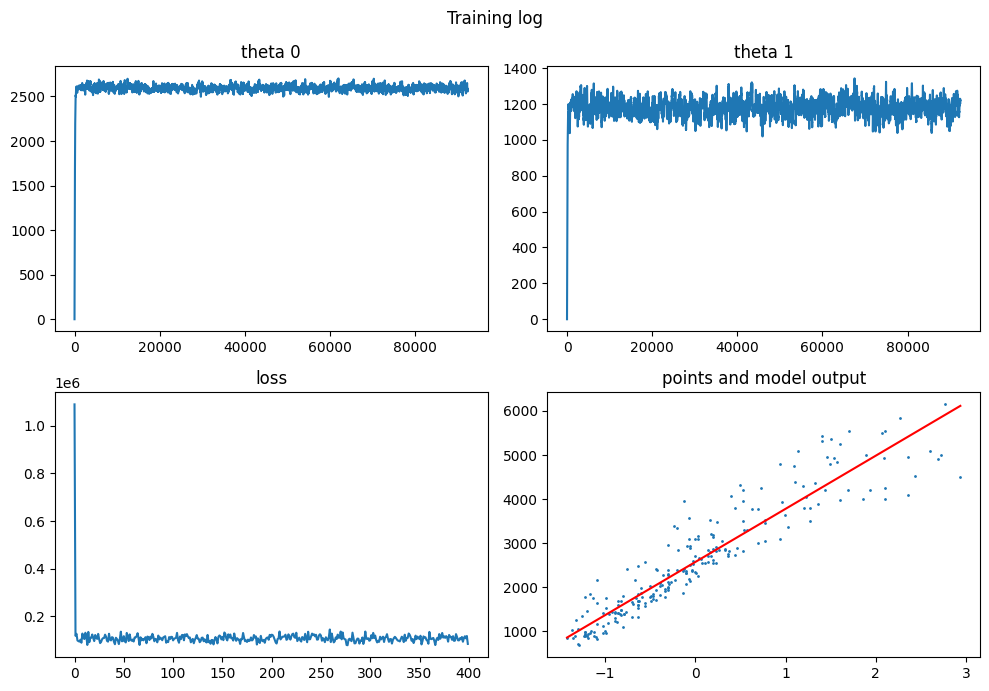

In [49]:
alpha = 0.001     # learning rate
beta_momentum_t0 = 0.9     # momentum factor for theta_0
beta_momentum_t1 = 0.9     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area_norm)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
        cg.backward()
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

t1_original_scale = t1 / living_area_std
t0_original_scale = t0 - t1 * living_area_mean / living_area_std

print("intercept (theta_0):", t0_original_scale)
print("slope (theta_1)    :", t1_original_scale)

y_hat_original_scale = t0_original_scale + t1_original_scale * living_area
J_original_scale = mse_loss(y_hat_original_scale, rent_price)

print("The total value of the loss is", J_original_scale)

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area_norm, rent_price)

Results without data normalisation:

intercept (theta_0): 661.4404040602716
slope (theta_1)    : 19.71535726817666
The total value of the loss is 104961.72706044678


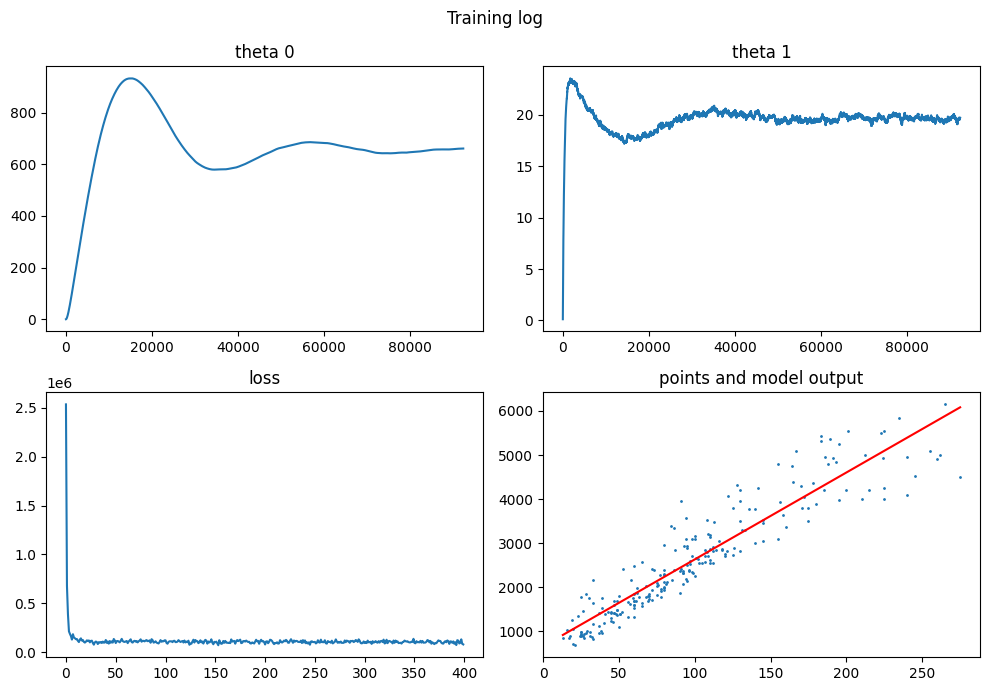

In [50]:
print("intercept (theta_0):", baseline_t0)
print("slope (theta_1)    :", baseline_t1)
print("The total value of the loss is", baseline_J)
plot_training_log(baseline_loss_evolution, baseline_t0_evolution, baseline_t1_evolution, living_area, rent_price)

- After normalizing the input data, the parameters converge much faster. Both theta_0 and theta_1 reach their final region very early in training, instead of slowly evolving over many epochs as in the non-normalized experiments.

- The evolution of the parameters is more balanced. Without normalization, theta_1 was strongly affected by the large scale of living_area, while theta_0 evolved much more slowly. With normalization, the input values are centered around 0 and scaled, so the gradients are better conditioned.

- The loss decreases sharply at the beginning and then remains around a stable plateau. Again the final loss is very similar to the previous results, which means normalization mainly improves the optimization process, not necessarily the final regression line.

- The learned parameters in the normalized space are not directly comparable with the non-normalized ones. After converting them back to the original scale, we obtain theta_0 ≈ 800 and theta_1 ≈ 18, which are consistent with the previous models.

- Compared with the experiments without normalization, we can use a much larger learning rate. Previously, the learning rate had to be very small because the raw living_area values produced large gradients for theta_1. After normalization, the gradients are smaller and more stable.